In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
from pathlib import Path

import ray
import torch
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from numpy.random import default_rng
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import WandbLogger
import wandb

In [35]:
import sys
sys.path.append("../")
sys.path.append("../../recurrently_predicting_hypergraphs/")

from convex_hull_dataset import get_ch_dl, ConvexHullData
import misc
import metrics

In [36]:
# Dataset
D_FEATS = 3
N_POINTS = torch.arange(30,31)
UNIT_NORM = False

# Model hyperparameter
CONFIG = "../configs/hgflow.yaml"
TRAIN = "../configs/train.yaml"

# Training hyperparameter
BATCH_SIZE = 64
LR = 0.0003
N_EPOCHS = 1000

# Miscellaneous
SEED = 123456
RNG = default_rng(SEED)
pl.seed_everything(SEED)
N_RAY = 0
if N_RAY > 0:
    ray.init(num_cpus=N_RAY,include_dashboard=False)

Global seed set to 123456


In [37]:
def get_collate_fn(max_facets, add_indicator=False, max_points=None, do_randomize=False):

    if do_randomize:
        print("Warning: randomizing the incidence matrix!")

    def pad(x, max_points, pad_value=float('nan')):
        if max_points is None:
            return x
        delta = max_points - x.size(0)
        if delta > 0:
            x = torch.cat([x, torch.full((delta, x.size(1)), pad_value)], dim=0)
        elif delta < 0:
            raise ValueError("max_points is smaller than the number of points!")
        return x
    
    def randomize(i):
        if not do_randomize:
            return i
        mask = torch.randint(0, 2, (i.shape[0], i.shape[1]), dtype=torch.bool)
        std = 0.01
        mean = 0.5
        out = mask*(std*torch.randn_like(i) - mean) + (~mask)*(std*torch.randn_like(i) + mean)
        return out

    if not add_indicator:
        def collate_fn(batch):
            points = []
            incidence = []
            for p, i in batch:
                points.append(pad(p, max_points))
                inc = torch.cat([i, torch.zeros(max_facets - i.size(0), i.size(1))],dim=0)
                inc = pad(inc, max_facets, pad_value=0)
                inc = randomize(inc)
                incidence.append(inc)
            return torch.stack(points), torch.stack(incidence)
        return collate_fn
    else:
        def collate_fn(batch):
            points = []
            incidence = []
            for p, i in batch:
                points.append(pad(p, max_points))
                nf = i.size(0)
                inc = torch.cat([i, torch.zeros(max_facets - nf, i.size(1))],dim=0)
                inc = torch.cat([inc, torch.zeros(max_facets, 1)], dim=1)
                inc[:nf,-1] = 1.
                inc = pad(inc, max_facets, pad_value=0)
                inc = randomize(inc)
                incidence.append(inc)
            return torch.stack(points), torch.stack(incidence)
        return collate_fn

In [38]:
train_dataset = ConvexHullData(n_range=N_POINTS,dim=D_FEATS,unit_norm=UNIT_NORM,length=20000)
assert train_dataset.max_facets <= 42, "max facets should be smaller than 40, got {}".format(train_dataset.max_facets)
collate_fn = get_collate_fn(max_facets=max(train_dataset.max_facets, 42), add_indicator=True, max_points=train_dataset.max_points, do_randomize=False)
train_dataset = torch.utils.data.Subset(train_dataset, torch.arange(0, 256)) #HACK
trainloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=False, num_workers=0)

In [7]:
# train_dataset = ConvexHullData(n_range=N_POINTS,dim=D_FEATS,unit_norm=UNIT_NORM,length=20000)
# collate_fn = get_collate_fn(max_facets=train_dataset.max_facets, add_indicator=True, max_points=train_dataset.max_points, do_randomize=False)
# trainloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True, num_workers=0)

In [8]:
for batch in trainloader:
    x, y = batch
    break

In [9]:
y.shape

torch.Size([64, 42, 31])

In [10]:
val_dataset = ConvexHullData(n_range=N_POINTS,dim=D_FEATS,unit_norm=UNIT_NORM,length=256)
assert val_dataset.max_facets <= 42, "max facets should be smaller than 40, got {}".format(val_dataset.max_facets)
valloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=False, num_workers=0)

In [11]:
for example in valloader:
    x, y  = example
    break

In [12]:
x = x[0]
y = y[0]

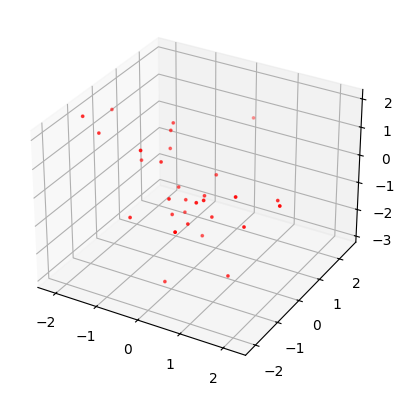

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x[:, 0], x[:, 1], x[:, 2], s=3, c='r', marker='o')
plt.show()

In [14]:
y[:,-1]

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.])

In [15]:
print("Number of hyperedges per point:")
print(y[:,:-1].sum(axis=0))
print("Number of points per hyperedge:")
print(y[:,:-1].sum(axis=1))

Number of hyperedges per point:
tensor([0., 0., 0., 0., 6., 0., 3., 3., 0., 0., 0., 3., 0., 0., 6., 0., 0., 0.,
        0., 3., 0., 6., 0., 0., 5., 0., 0., 6., 7., 0.])
Number of points per hyperedge:
tensor([3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.])


In [16]:
def plot_incidence_matrix(im, inverted=True):
    fig, ax = plt.subplots()
    if inverted:
        im = 1 - im
    ax.imshow(im, cmap='hot')
    ax.set_ylabel("Hyperedge")
    ax.set_xlabel("Vertex")
    plt.show()

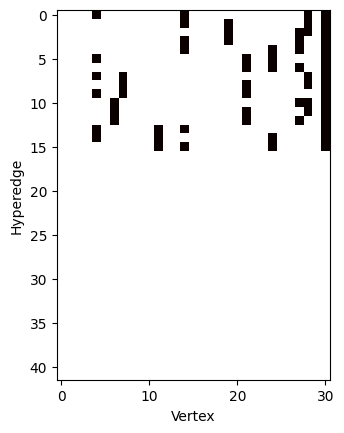

In [17]:
plot_incidence_matrix(y)

(array([1238.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
          64.]),
 array([0.        , 0.01      , 0.02      , 0.03      , 0.04      ,
        0.05      , 0.06      , 0.07      , 0.08      , 0.09      ,
        0.1       , 0.11      , 0.12      , 0.13      , 0.14      

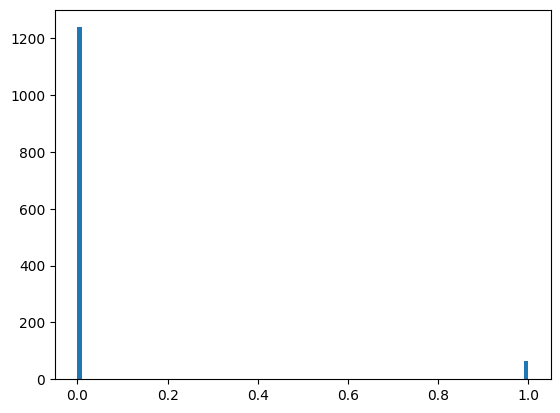

In [18]:
plt.hist(y.flatten(), bins=100)

In [44]:
from lights.hgflow_lightning import HGFlowLightning

In [45]:
model = HGFlowLightning(
    model_config=CONFIG,
    train_config=TRAIN,
)

In [46]:
data_type = "spherical" if UNIT_NORM else "normal"
wandb.init(
    settings=wandb.Settings(start_method='spawn'),
    name=f"{model.name} P{N_POINTS[0]}to{N_POINTS[-1]}",
    project=f"log_convex_hull_{data_type}",
    reinit=False,
)
logger = WandbLogger(
    log_model=True,
)
checkpoint_callback = ModelCheckpoint(
    monitor='loss/val',
    mode='min',
)

In [47]:
trainer = pl.Trainer(
    accelerator="mps",
    devices=1,
    max_epochs=300,
    logger=logger,
    callbacks=[checkpoint_callback],
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [48]:
# trainer.fit(model, trainloader, valloader)
trainer.fit(model, trainloader, trainloader)


  | Name | Type   | Params
--------------------------------
0 | net  | HGFlow | 833 K 
--------------------------------
833 K     Trainable params
0         Non-trainable params
833 K     Total params
3.334     Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=300` reached.


In [49]:
for batch in trainloader:
    break

In [50]:
bs, num_edges, num_nodes = batch[1].shape
im_0 = model.net.get_init_im(bs, num_edges, num_nodes, device=batch[1].device)
if model.FM is not None:
    # im_0 = 0.1*batch[1] - 0.5 + 0.1*im_0 # HACK!
    im_1, seq = model.sample(batch[0], im_0)
else:
    im_1 = model.net.forward(batch[0][:1], im_0[:1,:,:-1], t=None).detach()

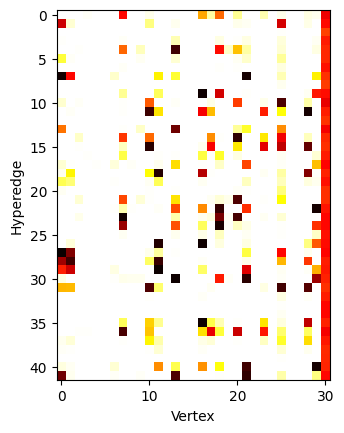

In [59]:
plot_incidence_matrix(im_1[0], inverted=True)

In [58]:
def convert_to_binary(im, threshold=0.5):
    return torch.where(im > threshold, 1, 0)

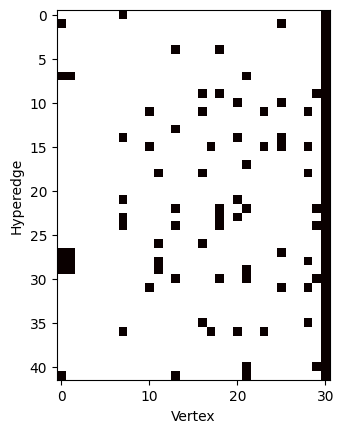

In [60]:
plot_incidence_matrix(convert_to_binary(im_1[0], threshold=0.5).cpu().numpy(), inverted=True)

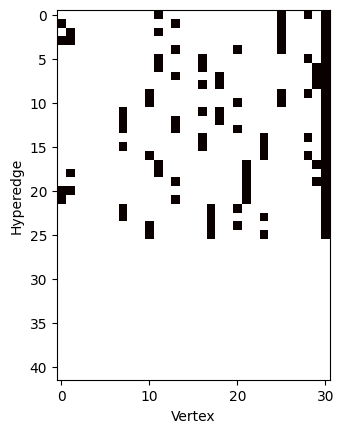

In [54]:
plot_incidence_matrix(batch[1][0].cpu().numpy(), inverted=True)

(array([ 1.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,
         2.,  0.,  2.,  0.,  1.,  2.,  3.,  2.,  4.,  6.,  5.,  9.,  6.,
         5.,  8., 12.,  8.,  7., 16., 16., 10., 13., 10., 14., 19., 23.,
        16., 18., 28., 21., 22., 29., 19., 25., 39., 30., 37., 32., 41.,
        36., 38., 30., 28., 34., 36., 35., 32., 26., 32., 19., 25., 31.,
        26., 30., 32., 25., 26., 14., 23., 18., 17., 16.,  8., 10., 12.,
         4.,  8.,  9.,  9.,  5.,  4.,  3.,  8.,  3., 11.,  3.,  4.,  2.,
         2.,  1.,  0.,  0.,  0.,  1.,  0.,  2.,  1.]),
 array([-3.62523603, -3.5589416 , -3.49264741, -3.42635298, -3.36005855,
        -3.29376411, -3.22746992, -3.16117549, -3.09488106, -3.02858686,
        -2.96229243, -2.895998  , -2.82970381, -2.76340938, -2.69711494,
        -2.63082075, -2.56452632, -2.49823189, -2.43193746, -2.36564326,
        -2.29934883, -2.2330544 , -2.16676021, -2.10046577, -2.03417134,
        -1.96787703, -1.90158272, -1.83528829, -1.76899397, -1.702699

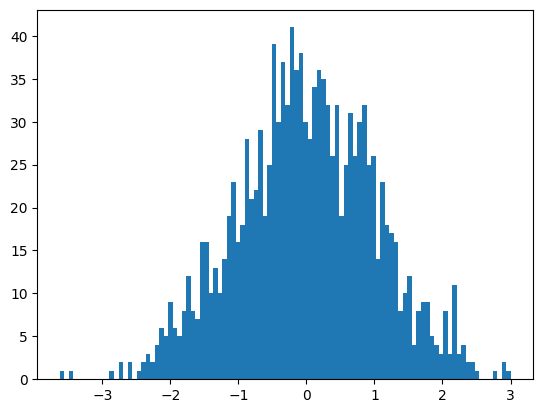

In [55]:
plt.hist(im_0[0].flatten(), bins=100)

In [56]:
u_values = []

with torch.no_grad():
    for batch in trainloader:
        x, y = batch
        im_0 = model.net.get_init_im(x.shape[0], y.shape[1], y.shape[2], device=y.device)
        # im_0 = 0.1*batch[1] - 0.5 + 0.1*im_0 # HACK!
        t = torch.rand(x.shape[0], device=x.device)
        u_values.append(model.net.forward(x, im_0[:,:,:-1], t=t))

u_values = torch.concatenate(u_values, axis=0)

(array([2.55994e+05, 1.04060e+04, 5.67000e+03, 3.65600e+03, 2.72500e+03,
        2.26300e+03, 1.84800e+03, 1.54700e+03, 1.40500e+03, 1.25900e+03,
        1.04800e+03, 9.59000e+02, 8.85000e+02, 8.67000e+02, 7.93000e+02,
        7.38000e+02, 6.71000e+02, 6.52000e+02, 6.24000e+02, 5.65000e+02,
        5.61000e+02, 5.70000e+02, 4.75000e+02, 4.97000e+02, 4.71000e+02,
        4.36000e+02, 4.16000e+02, 4.54000e+02, 4.01000e+02, 4.26000e+02,
        3.77000e+02, 3.83000e+02, 3.48000e+02, 3.39000e+02, 3.52000e+02,
        2.87000e+02, 3.31000e+02, 3.01000e+02, 2.90000e+02, 3.24000e+02,
        3.12000e+02, 2.75000e+02, 2.72000e+02, 3.01000e+02, 2.78000e+02,
        2.71000e+02, 2.92000e+02, 2.71000e+02, 3.07000e+02, 3.09000e+02,
        3.84000e+02, 5.03000e+02, 6.49000e+02, 8.56000e+02, 1.07800e+03,
        1.28900e+03, 1.33800e+03, 1.40400e+03, 1.31000e+03, 1.23200e+03,
        1.00100e+03, 8.82000e+02, 6.78000e+02, 6.26000e+02, 5.14000e+02,
        4.05000e+02, 3.46000e+02, 3.30000e+02, 3.08

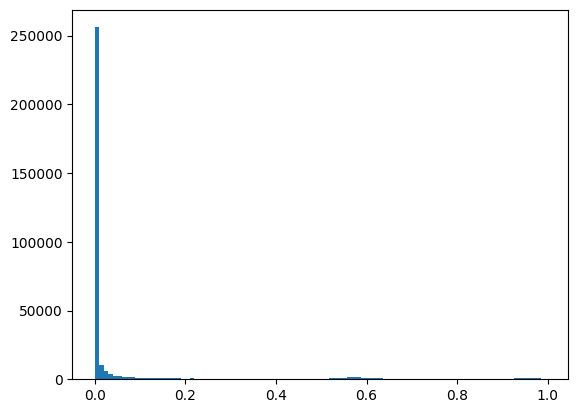

In [57]:
plt.hist(u_values.flatten(), bins=100)